# Question1: Community detection, degree heterogeneity, and `graph-tool`

Installing graph-tool (https://graph-tool.skewed.de)

---


To import a library that's not in Colaboratory by default, you can use `!apt-get install`.

But since graph-tool is not in the official repository, we need to add it to the list.

In [1]:
!wget https://downloads.skewed.de/skewed-keyring/skewed-keyring_1.0_all_$(lsb_release -s -c).deb
!dpkg -i skewed-keyring_1.0_all_$(lsb_release -s -c).deb
!echo "deb [signed-by=/usr/share/keyrings/skewed-keyring.gpg] https://downloads.skewed.de/apt $(lsb_release -s -c) main" > /etc/apt/sources.list.d/skewed.list
!apt-get update
!apt-get install python3-graph-tool python3-matplotlib python3-cairo

--2024-11-12 15:43:09--  https://downloads.skewed.de/skewed-keyring/skewed-keyring_1.0_all_jammy.deb
Resolving downloads.skewed.de (downloads.skewed.de)... 49.12.93.194
Connecting to downloads.skewed.de (downloads.skewed.de)|49.12.93.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23192 (23K) [application/x-debian-package]
Saving to: ‘skewed-keyring_1.0_all_jammy.deb’

skewed-keyring_1.0_ 100%[===================>]  22.65K  --.-KB/s    in 0.1s    

2024-11-12 15:43:09 (221 KB/s) - ‘skewed-keyring_1.0_all_jammy.deb’ saved [23192/23192]

Selecting previously unselected package skewed-keyring.
(Reading database ... 123624 files and directories currently installed.)
Preparing to unpack skewed-keyring_1.0_all_jammy.deb ...
Unpacking skewed-keyring (1.0) ...
Setting up skewed-keyring (1.0) ...
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jam

In [2]:
# Colab uses a Python install that deviates from the system's! Bad colab! We need some workarounds.
!apt purge python3-cairo
!apt install libcairo2-dev pkg-config python3-dev
!pip install --force-reinstall pycairo
!pip install zstandard

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following packages will be REMOVED:
  python3-cairo*
0 upgraded, 0 newly installed, 1 to remove and 56 not upgraded.
After this operation, 310 kB disk space will be freed.
(Reading database ... 132031 files and directories currently installed.)
Removing python3-cairo:amd64 (1.20.1-3build1) ...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-dev is already the newest version (3.10.6-1~22.04.1).
python3-dev set to manually installed.
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libblkid-dev libblkid1 libcairo-script-interpreter2 libffi-dev libglib2.0-dev libglib2.0-dev-bin
  libice-dev liblzo2-2 libmount-dev libmount1 libpixman-1-dev libselinux1-dev libsepol-dev
  lib

Now we can use graph-tool as any other Python module



In [3]:
# from graph_tool.all import *

# g = collection.data["celegansneural"]
# state = minimize_nested_blockmodel_dl(g)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import graph_tool.all as gt
import random

## (a)


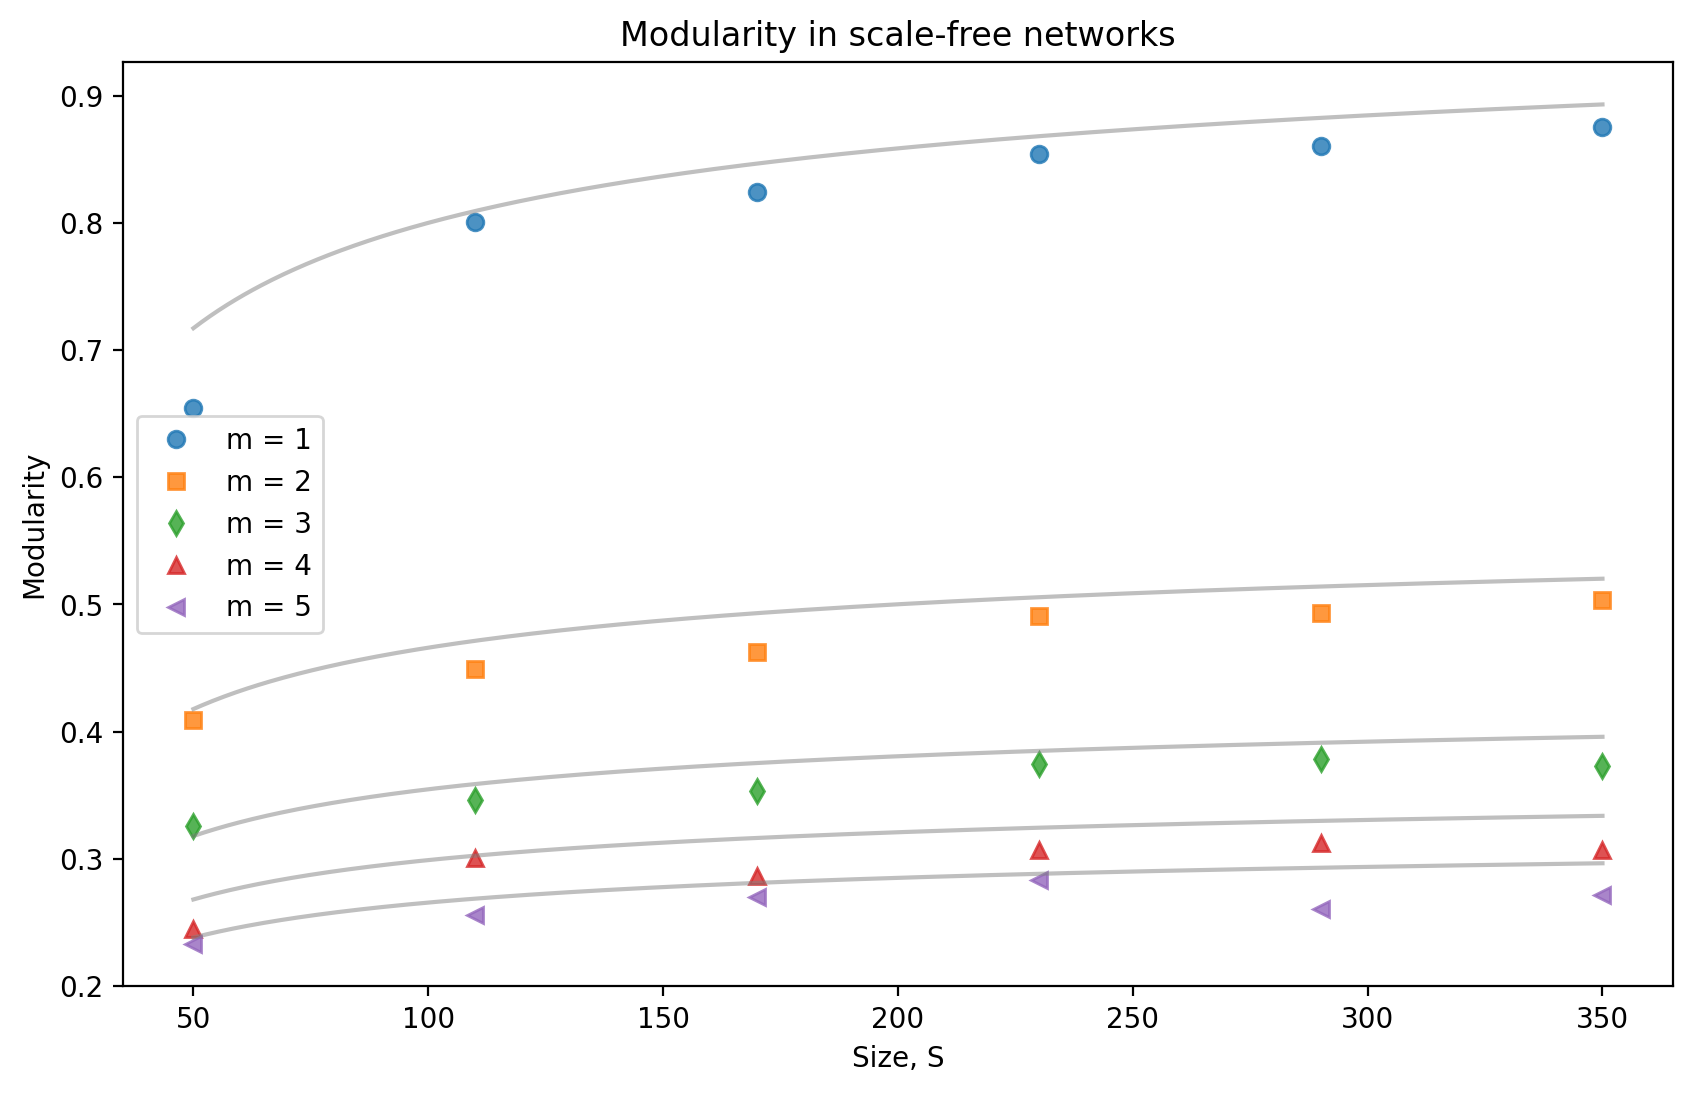

In [5]:
# eq1
def calculate_modularity(G):
    L = G.number_of_edges()
    communities = nx.community.greedy_modularity_communities(G)
    M = 0
    for c in communities:
        subgraph = G.subgraph(c)
        ls = subgraph.number_of_edges()
        ds = sum([G.degree(n) for n in c])
        M += (ls / L - (ds / (2 * L)) ** 2)
    return M

# eq21
def predict_modularity(S, m, a=0.165):
    return (a + (1 - a) / m) * (1 - 2 / np.sqrt(S))

m_values = [1, 2, 3, 4, 5] # preferential connections
S_values = np.linspace(50, 350, 6, dtype=int)  # network size S
smooth_S_values = np.linspace(50, 350, 500)
markers = ['o', 's', 'd', '^', '<']


fig, ax = plt.subplots(1,1,figsize=(10,6),dpi=200)
for idx, m in enumerate(m_values):
    modularity_values = []
    for S in S_values:
        G = nx.barabasi_albert_graph(S, m)
        M = calculate_modularity(G)
        modularity_values.append(M)

    ax.plot(S_values, modularity_values,
            label=f'm = {m}', marker=markers[idx], markersize=6, linestyle='', alpha=0.8)
    predicted_values = [predict_modularity(S, m) for S in smooth_S_values]
    ax.plot(smooth_S_values, predicted_values, linestyle='-', color='grey', alpha=0.5)

plt.xlabel('Size, S')
plt.ylabel('Modularity')
plt.title('Modularity in scale-free networks')
plt.legend()
plt.savefig('1a.png', dpi=425, bbox_inches='tight')
plt.show()

Results:

1. For each fixed value of m, modularity tends to be stabilize as the network size S increases.
2. As the value of m increases, modularity decreases because each node connects to more existing nodes, making the network more densely connected and hard to partition. Lower m values like m=1 and m=2 exhibit higher modularity, indicating that the network is easier to divide into high quality modular structures.
3. The predicted and calculated values show same trend. The deviation is likely due to the use of `greedy_modularity_communities` from networkX to find the community partition with the largest modularity, rather than using a simulated annealing algorithm (which seems only available in an R package, so we used the NetworkX function here).



## (b)

In [6]:
g = gt.collection.ns["polblogs"]
g = gt.extract_largest_component(g, directed=False)

# degree-corrected
state_dc  = gt.minimize_blockmodel_dl(g, state_args=dict(deg_corr=True), multilevel_mcmc_args=dict(B_max=2))

# non-degree-corrected
state_ndc = gt.minimize_blockmodel_dl(g, state_args=dict(deg_corr=False), multilevel_mcmc_args=dict(B_max=2))



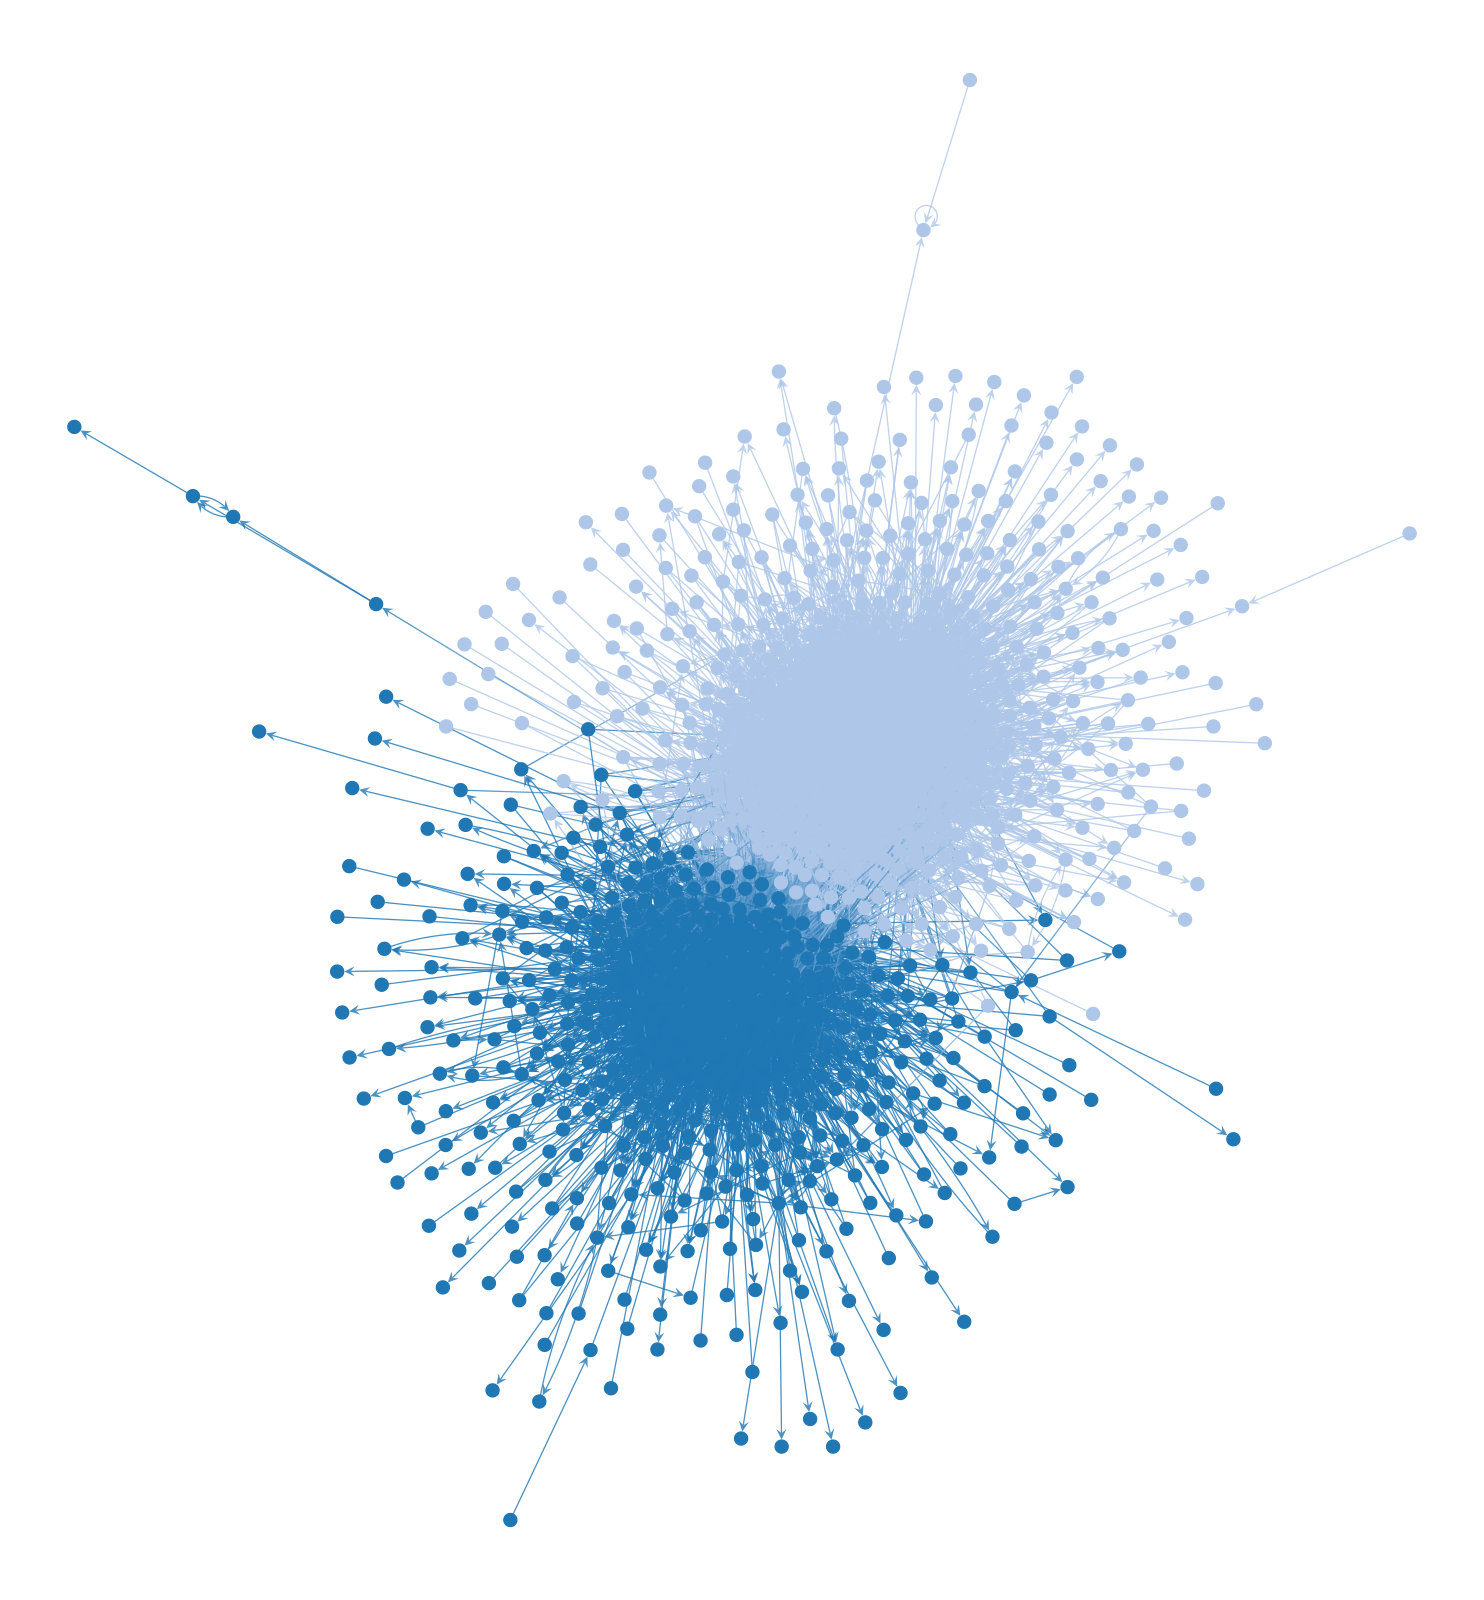

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x78345e4a7430, at 0x783463d27670>

In [7]:
state_dc.draw(output_size=(800, 800))

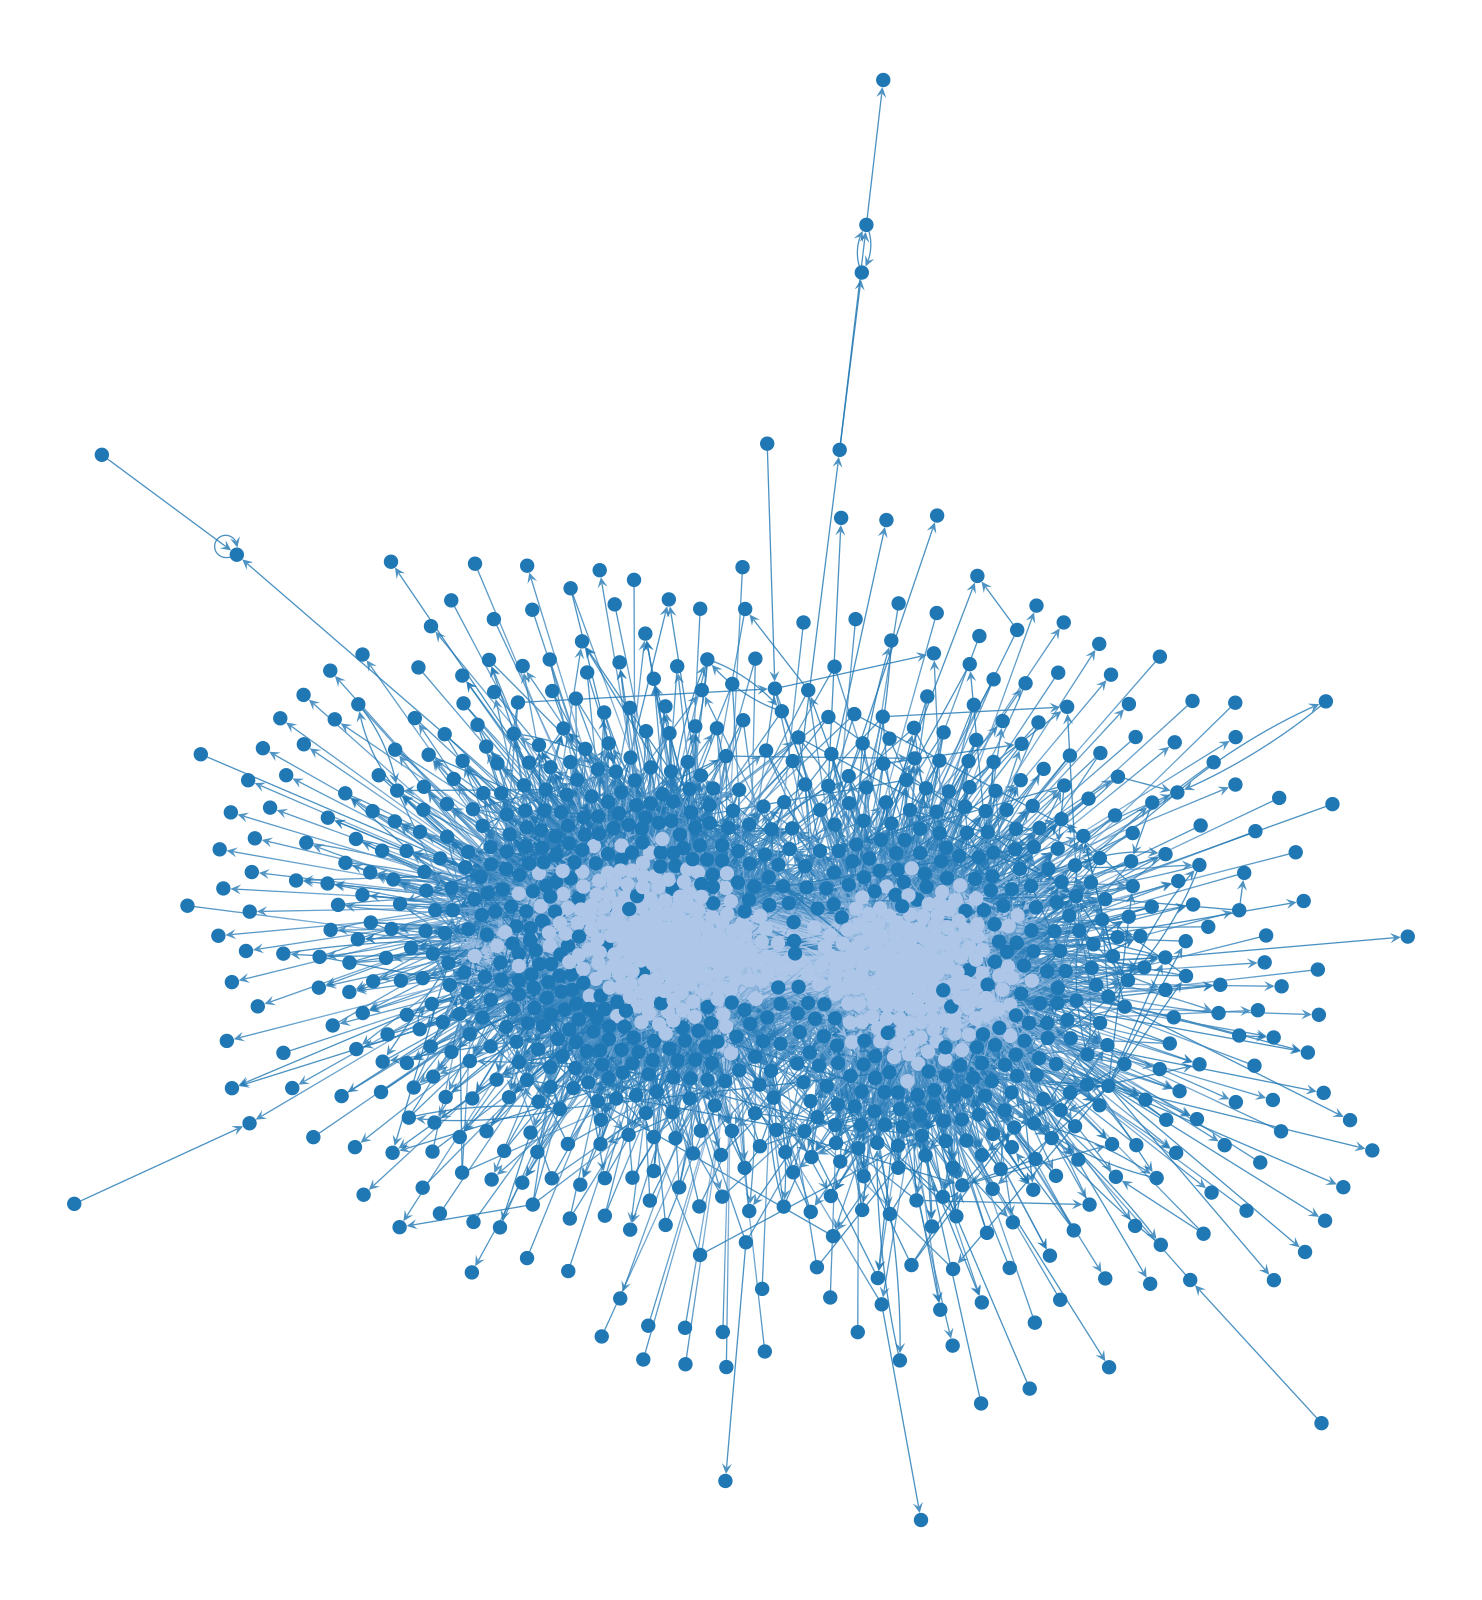

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x78345e4a7430, at 0x78345e4a5210>

In [8]:
state_ndc.draw(output_size=(800, 800))

In [9]:
import matplotlib

In [10]:
pos = gt.sfdp_layout(g)
def rotate(pos, a):
    """Rotate the positions by `a` degrees."""
    theta = np.radians(a)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    x, y = pos.get_2d_array()
    cm = np.array([x.mean(), y.mean()])
    return pos.t(lambda x: R @ (x.a - cm) + cm)

pos = rotate(pos, 160)

dprms = dict(fmt="png",  output_size=(600, 600), output="1b_dc.png")
gt.graph_draw(g, pos, vertex_fill_color=state_dc.get_blocks(), vcmap=matplotlib.cm.coolwarm,
           vcnorm=matplotlib.colors.Normalize(vmin=0, vmax=1), **dprms);

In [11]:
dprms = dict(fmt="png",  output_size=(600, 600), output="1b_ndc.png")
gt.graph_draw(g, pos, vertex_fill_color=state_ndc.get_blocks(), vcmap=matplotlib.cm.coolwarm,
           vcnorm=matplotlib.colors.Normalize(vmin=0, vmax=1), **dprms);

## (c)

In [12]:
print("Degree-corrected DL:\t", state_dc.entropy())

print("Non-degree-corrected DL:\t", state_ndc.entropy())

Degree-corrected DL:	 63428.9528760646
Non-degree-corrected DL:	 83142.50904646632


Fit new degree-corrected and non-degree-corrected models to the largest component
of the polblogs dataset. After initializing BlockState with B=2, use
a for loop of 1,000 iterations to collect the description lengths of each model
at every step using the mcmc sweep function (setting niter=1; during the
for-loop do not enforce the number of blocks to be 2 ). Visualize both of these
curves in a single plot, labeled properly, and comment on your observation.

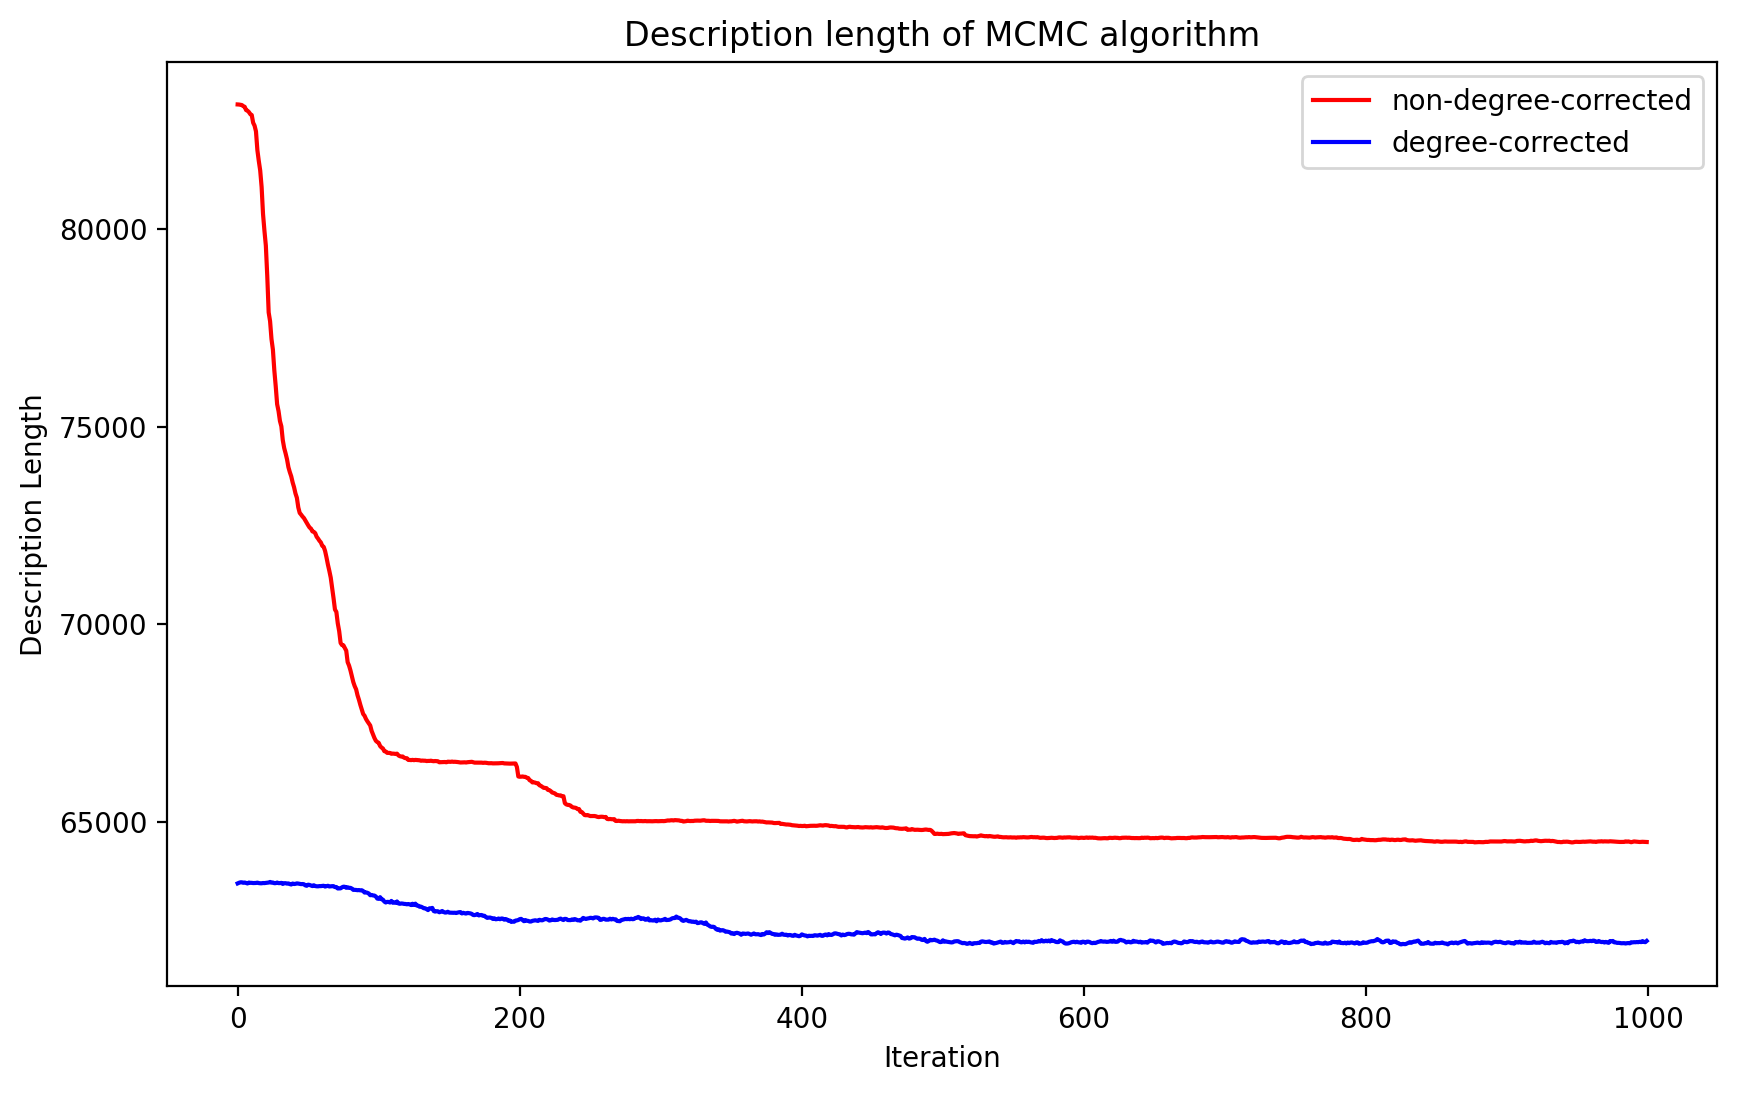

In [13]:
iter = 1000
non_degree_lengths = []
degree_lengths = []

for _ in range(iter):
    state_ndc.mcmc_sweep(niter=1)
    non_degree_lengths.append(state_ndc.entropy())

    state_dc.mcmc_sweep(niter=1)
    degree_lengths.append(state_dc.entropy())


fig, ax = plt.subplots(1,1,figsize=(10,6),dpi=200)
plt.plot(non_degree_lengths, label="non-degree-corrected", color="red")
plt.plot(degree_lengths, label="degree-corrected", color="blue")
plt.xlabel("Iteration")
plt.ylabel("Description Length")
plt.title("Description length of MCMC algorithm")
plt.legend()
plt.savefig('1c.png', dpi=425, bbox_inches='tight')
plt.show()


Result:
1. The description length of the degree-corrected model is significantly lower than that of the non-degree-corrected model, indicating that the degree-corrected model is more suitable for networks with heterogeneous node degree distributions like `polblogs`.
2. The non-degree-corrected model consistently has a higher description length, mainly because it does not take node degree distribution into account, thereby increasing the cost of describing the actual structure of the network.
3. In the first 200 iterations, the description length decreases rapidly, and after that, it gradually stabilizes. Both models show similar convergence patterns, indicating that the MCMC algorithm can effectively find the optimal community partition.

##  (d)

Explore the model selection section in the graph-tool documentation and
Section VIIA and VIIB in https://arxiv.org/abs/1705.10225. Figure 7 in
this article should validate whether your approach in (b) above is on the right
track. Summarize the intuition and formalism behind degree correction in the
(microcanonical) stochastic block model framework. Use Figure 8 as your guide.

Intuition:

In Figure 7, the SBM divides the network into low and high-degree groups, whereas the DC-SBM prefers a division into political factions. The SBM partitions the network by maximizing modularity without considering degree distributions. However, the DC-SBM can better fit networks with heterogeneous degree distributions (such as most real networks) because it incorporates node degree parameters into the model.


Formalism:

1. Sample edge counts: Given the partition of communities, the model samples the number of edges $e_{rs}$ between each pair of blocks.
2. Sample node degrees: Based on the edge counts between blocks, the model then generates a degree distribution for nodes within each block.
3. Generate the network: With the number of edges and node degrees determined, the model creates connections between nodes.

# Question 2. Core concepts in machine learning

## (a)

Pick a machine learning algorithm and summarize, in your own words, how it works and what it’s useful for.




Mahesh, B. (2020). Machine learning algorithms-a review. International Journal of Science and Research (IJSR).[Internet], 9(1), 381-386.

1. Random Forest

Here shows the structure of current machine learning algorithms. For this question we choose Random Forest (RF) algorithm. RF belongs to the Ensemble Learning, more specifically, Bagging. Bagging (Bootstrap Aggregating) improves overall stability and accuracy by averaging or voting on the results of multiple models, and RF is a method based on Bagging.

2. How it works
- RF is an integrated algorithm composed of multiple decision trees. A decision tree is a single model that uses a series of rules to classify or regress data.
- RF randomly divide the dataset into multiple subsets, each of which generates a decision tree. The final prediction result is given by the ensemble of these trees (majority vote for classification tasks or average for regression tasks).

Step 1: Select random K data points from the training set.

Step 2: Build the decision trees associated with the selected data points(Subsets).

Step 3: Choose the number N for decision trees that you want to build.

Step 4: Repeat Step 1 and 2.

Step 5: For new data points, find the predictions of each decision tree, and assign the new data points to the category that wins the majority votes.


https://www.geeksforgeeks.org/random-forest-algorithm-in-machine-learning/#


3. What it's useful for: scenarios that require high accuracy but not high interpretability, such as credit scoring, fraud detection, and medical diagnosis, because this algorithm reduces the risk of overfitting and improving overall prediction performance.

## (b)

What aspect of the model is most confusing to you? Explain why it is confusing
conceptually and walk us through your own understanding in whatever format
works best for you.

The aspect of the model that is most confusing is: How does Random Forest avoid overfitting?

[figure]

Combined with this figure, let's go through the whole process and explain in detail how Random Forest avoids overfitting through multiple steps.

1. Model training stage
- Multiple decision trees: Random Forest randomly extracts different subsets from the training data, so the training data for each tree is different. This prevents each tree from overfitting to the same data and enhances the robustness of the model.
- Feature subset selection: Since each tree is trained using only a subset of features, this reduces the model's reliance on certain features, making the model less sensitive to noise in specific features and thus reducing the possibility of overfitting.
- Hyperparameter control: Finetuning hyperparameters helps reduce the risk of overfitting, including:
  - Number of trees (`n_estimators`): A higher value for n_estimators can improve stability and prediction performance, although it also increases computation time.
  - Maximum depth of the tree (`max_depth`): Limiting the maximum depth of each tree can prevent it from becoming too complex, thereby reducing the tendency of a single tree to overfit.
  - Minimum number of samples per leaf node (`min_samples_leaf`): Increasing `min_samples_leaf` can avoid each tree being sensitive to small samples and reduce the risk of overfitting.

  This is not absolute; all parameters should be considered together.


2. Model testing stage
- Bagging: Random Forest combines the predictions of multiple trees by majority voting (for classification) or averaging (for regression). If individual trees overfit the training data, their influence will be neutralized by the results of other trees in the voting or averaging process. In the figure, each tree gives its own result based on the training data (marked as Class A or Class B in the figure), and the final output is Class A because it is the majority.

Here is an example of how random forests can avoid overfitting.



In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# load dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# initial hyperparameters
rf_classifier = RandomForestClassifier(
    n_estimators=5,  # number of trees
    max_depth=3,     # maximum depth of each tree
    min_samples_leaf=2,  # minimum number of samples per leaf node
    max_features='sqrt',  # feature subset used for each split
    random_state=42,
    bootstrap=True  # whether to use bootstrap samples for each tree
)

# train the initial model
rf_classifier.fit(X_train, y_train)

# print all features and selected features for each tree
all_features = list(X_train.columns)
print("All features:", all_features)

for idx, tree in enumerate(rf_classifier.estimators_):
    # [evidence of multiple decision trees!!!]
    sample_indices = tree.random_state
    print(f"\nTree {idx+1} uses a unique sample subset from training data with random state: {sample_indices}")

    # [evidence of feature subset selection!!!]
    feature_indices = tree.feature_importances_ > 0  # features used by the tree
    selected_features = X_train.columns[feature_indices]
    print(f"Tree {idx+1} selected features: {list(selected_features)}")

# prediction
all_tree_predictions = np.array([tree.predict(X_test) for tree in rf_classifier.estimators_])
print("\nPredictions from each tree before Bagging:")
for i, prediction in enumerate(all_tree_predictions):
    print(f"Tree {i+1} prediction: {prediction}")

# [Bagging!!!]
final_prediction = rf_classifier.predict(X_test)
print("\nFinal prediction after Bagging (majority vote):")
print(final_prediction)


All features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Tree 1 uses a unique sample subset from training data with random state: 1608637542
Tree 1 selected features: ['sepal length (cm)', 'petal length (cm)', 'petal width (cm)']

Tree 2 uses a unique sample subset from training data with random state: 1273642419
Tree 2 selected features: ['petal length (cm)', 'petal width (cm)']

Tree 3 uses a unique sample subset from training data with random state: 1935803228
Tree 3 selected features: ['petal length (cm)', 'petal width (cm)']

Tree 4 uses a unique sample subset from training data with random state: 787846414
Tree 4 selected features: ['sepal length (cm)', 'petal length (cm)']

Tree 5 uses a unique sample subset from training data with random state: 996406378
Tree 5 selected features: ['petal length (cm)', 'petal width (cm)']

Predictions from each tree before Bagging:
Tree 1 prediction: [1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 

In [49]:
# Let's see how hyperparameter controls the overfitting
# Both Iris and Titanic datasets are small, so all RandomForestClassifier modle will achieve ideal results

# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_data = pd.read_csv(url)

# Drop rows with missing target values
titanic_data = titanic_data.dropna(subset=['Survived'])

# Select relevant features and target variable
X = titanic_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = titanic_data['Survived']

# Convert categorical variable 'Sex' to numerical using .loc
X.loc[:, 'Sex'] = X['Sex'].map({'female': 0, 'male': 1})

# Handle missing values in the 'Age' column using .loc
X.loc[:, 'Age'].fillna(X['Age'].median(), inplace=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_leaf=1
)
rf_classifier.fit(X_train, y_train)

# example 1: increase number of trees
rf_classifier_example1 = RandomForestClassifier(
    n_estimators=100,  # increase number of trees
    max_depth=3,
    min_samples_leaf=1
)
rf_classifier_example1.fit(X_train, y_train)


# example 2: reduce max depth
rf_classifier_example2 = RandomForestClassifier(
    n_estimators=50,
    max_depth=1,     # reduce max depth
    min_samples_leaf=1
)
rf_classifier_example2.fit(X_train, y_train)


# example 3: increase min_samples_leaf
rf_classifier_example3 = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_leaf=2,
)
rf_classifier_example3.fit(X_train, y_train)

# make predictions on the test set with each model
y_pred_initial = rf_classifier.predict(X_test)
y_pred_example1 = rf_classifier_example1.predict(X_test)
y_pred_example2 = rf_classifier_example2.predict(X_test)
y_pred_example3 = rf_classifier_example3.predict(X_test)

# evaluate each model
print("\nInitial Model Evaluation:")
accuracy_initial = accuracy_score(y_test, y_pred_initial)
print(f"Accuracy: {accuracy_initial:.2f}")
print(classification_report(y_test, y_pred_initial))

print("\nExample 1 Model Evaluation:")
accuracy_example1 = accuracy_score(y_test, y_pred_example1)
print(f"Accuracy: {accuracy_example1:.2f}")
print(classification_report(y_test, y_pred_example1))

print("\nExample 2 Model Evaluation:")
accuracy_example2 = accuracy_score(y_test, y_pred_example2)
print(f"Accuracy: {accuracy_example2:.2f}")
print(classification_report(y_test, y_pred_example2))

print("\nExample 3 Model Evaluation:")
accuracy_example3 = accuracy_score(y_test, y_pred_example3)
print(f"Accuracy: {accuracy_example3:.2f}")
print(classification_report(y_test, y_pred_example3))



Initial Model Evaluation:
Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.76      0.91      0.83       105
           1       0.83      0.58      0.68        74

    accuracy                           0.78       179
   macro avg       0.79      0.75      0.76       179
weighted avg       0.79      0.78      0.77       179


Example 1 Model Evaluation:
Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.76      0.90      0.83       105
           1       0.81      0.59      0.69        74

    accuracy                           0.78       179
   macro avg       0.79      0.75      0.76       179
weighted avg       0.78      0.78      0.77       179


Example 2 Model Evaluation:
Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.73      0.96      0.83       105
           1       0.90      0.49      0.63        74

    accuracy                           0.77       17

In [12]:
# Let's use a larger dataset

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

newsgroups_data = fetch_20newsgroups(subset='all', categories=['alt.atheism', 'sci.space'])

X = newsgroups_data.data
y = newsgroups_data.target
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(
    n_estimators=5,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42
)
rf_classifier.fit(X_train, y_train)


rf_classifier_example1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42
)
rf_classifier_example1.fit(X_train, y_train)


rf_classifier_example2 = RandomForestClassifier(
    n_estimators=5,
    max_depth=8,
    min_samples_leaf=1,
    random_state=42
)
rf_classifier_example2.fit(X_train, y_train)


rf_classifier_example3 = RandomForestClassifier(
    n_estimators=5,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
rf_classifier_example3.fit(X_train, y_train)


print("\nInitial Model Evaluation:")
y_pred_initial = rf_classifier.predict(X_test)
accuracy_initial = accuracy_score(y_test, y_pred_initial)
print(f"Accuracy: {accuracy_initial:.2f}")
print(classification_report(y_test, y_pred_initial))

print("\nExample 1 Model Evaluation (n_estimators: 5 -> 200):")
y_pred_example1 = rf_classifier_example1.predict(X_test)
accuracy_example1 = accuracy_score(y_test, y_pred_example1)
print(f"Accuracy: {accuracy_example1:.2f}")
print(classification_report(y_test, y_pred_example1))

print("\nExample 2 Model Evaluation (max_depth: 10 -> 8):")
y_pred_example2 = rf_classifier_example2.predict(X_test)
accuracy_example2 = accuracy_score(y_test, y_pred_example2)
print(f"Accuracy: {accuracy_example2:.2f}")
print(classification_report(y_test, y_pred_example2))

print("\nExample 3 Model Evaluation (min_samples_leaf: 1 -> 5):")
y_pred_example3 = rf_classifier_example3.predict(X_test)
accuracy_example3 = accuracy_score(y_test, y_pred_example3)
print(f"Accuracy: {accuracy_example3:.2f}")
print(classification_report(y_test, y_pred_example3))



Initial Model Evaluation:
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       157
           1       0.89      0.92      0.90       201

    accuracy                           0.89       358
   macro avg       0.89      0.88      0.89       358
weighted avg       0.89      0.89      0.89       358


Example 1 Model Evaluation (n_estimators: 5 -> 200):
Accuracy: 0.97
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       157
           1       0.95      1.00      0.97       201

    accuracy                           0.97       358
   macro avg       0.97      0.96      0.97       358
weighted avg       0.97      0.97      0.97       358


Example 2 Model Evaluation (max_depth: 10 -> 8):
Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       157
           1       0.90      0.94      0.92       201

    ac

## (c)

Create a flashcard for the difficult concept you just walked us through. Use
matplotlib, LaTeX, and any other illustrative techniques you feel are appropriate.

(There's nothing here ☹)

# Question 3. Random walk dynamics


## (a)

Write a function from scratch that computes the commute time of a single random walker between nodes i and j in a network. Test this on the karate club graph by printing the commute time between 3 randomly selected pairs of nodes.

In [41]:
# commute time is how long it took to get from i to j back to i
# which is the same as first passage time i to j + first passage time j to i

def first_passage_time(G, i, j, iter=100):
    """Calculate the first passage time between node i and node j in graph G."""
    t = 0
    adj_list = {node: list(G.neighbors(node)) for node in G.nodes()}
    for _ in range(iter):  # simulate multiple random walks
        curr = i
        steps = 0
        while curr != j:
            curr = random.choice(adj_list[curr])
            steps += 1
        t += steps
    return t / iter

G = nx.karate_club_graph()
nodes = list(G.nodes)
for _ in range(3):
    i, j = random.sample(nodes, 2)
    commute_time = first_passage_time(G, i, j) + first_passage_time(G, j, i)
    print(f"Commute time between {i} and {j}: {commute_time}")


Commute time between 0 and 6: 63.67
Commute time between 31 and 3: 76.65
Commute time between 10 and 30: 142.0


## (b)

Calculate the mean commute time between pairs of nodes in Erdős-Rényi networks with N = 500 and ⟨k⟩ = 8 and Barabási-Albert networks with N = 500 and m = 4. Compute the average commute time across all nodes in the network, then average this value across 10 samples from each of these two graph models. Comment on any differences you observe.

In [42]:
def mean_commute_time(G, iter=10, sample_size=100):
    nodes = list(G.nodes())
    commute_times = []

    random_pairs = random.sample([(i, j) for i in range(len(nodes)) for j in range(i + 1, len(nodes))], sample_size)

    for i, j in random_pairs:
      commute_time = first_passage_time(G, nodes[i], nodes[j], iter=10) + \
        first_passage_time(G, nodes[j], nodes[i], iter=10)
      commute_times.append(commute_time)

    return np.mean(commute_times)

# ER network
er_commute_times = []
for _ in range(10):
    G_er = nx.erdos_renyi_graph(n=500, p=8/500)
    er_commute_times.append(mean_commute_time(G_er))
er_mean = np.mean(er_commute_times)
print(f"Mean commute time for ER network: {er_mean}")

Mean commute time for ER network: 1351.9699000000003


In [46]:
er_nodes = list(G_er.nodes)
for _ in range(3):
    i, j = random.sample(er_nodes, 2)
    commute_time = first_passage_time(G_er, i, j) + first_passage_time(G_er, j, i)
    print(f"Commute time between {i} and {j}: {commute_time}")

Commute time between 252 and 137: 1034.25
Commute time between 186 and 234: 968.19
Commute time between 40 and 445: 624.75


In [66]:
G_er = nx.erdos_renyi_graph(n=500, p=8/(500-1))
G_er.number_of_edges()


1984

In [65]:
G_ba = nx.barabasi_albert_graph(n=500, m=4)
G_ba.number_of_edges()

1984

In [ ]:
# from multiprocessing import Pool

# def commute_time_pair(args):
#     G, i, j, iter = args
#     return first_passage_time(G, i, j, iter) + first_passage_time(G, j, i, iter)

# def mean_commute_time(G, iter=10, sample_size=100, processes=4):
#     nodes = list(G.nodes())
#     random_pairs = random.sample([(nodes[i], nodes[j]) for i in range(len(nodes)) for j in range(i + 1, len(nodes))], sample_size)
#     args = [(G, i, j, iter) for i, j in random_pairs]

#     with Pool(processes=processes) as pool:
#         commute_times = pool.map(commute_time_pair, args)

#     return np.mean(commute_times)

# # ER network
# er_commute_times = []
# for _ in range(10):
#     G_er = nx.erdos_renyi_graph(n=500, p=8/500)
#     er_commute_times.append(mean_commute_time(G_er, iter=10, sample_size=100, processes=4))
# er_mean = np.mean(er_commute_times)
# print(f"Mean commute time for ER network: {er_mean}")

In [44]:
# BA network
ba_commute_times = []
for _ in range(10):
    G_ba = nx.barabasi_albert_graph(n=500, m=4)
    ba_commute_times.append(mean_commute_time(G_ba))
ba_mean = np.mean(ba_commute_times)

print(f"Mean commute time for BA network: {ba_mean}")


Mean commute time for BA network: 1599.7214


In [49]:
# BA network when m = 2
ba_commute_times = []
for _ in range(10):
    G_ba = nx.barabasi_albert_graph(n=500, m=2)
    ba_commute_times.append(mean_commute_time(G_ba))
ba_mean = np.mean(ba_commute_times)

print(f"Mean commute time for BA network when m = 2: {ba_mean}")

Mean commute time for BA network: 1939.2261999999998


In [50]:
# BA network when m = 6
ba_commute_times = []
for _ in range(10):
    G_ba = nx.barabasi_albert_graph(n=500, m=6)
    ba_commute_times.append(mean_commute_time(G_ba))
ba_mean = np.mean(ba_commute_times)

print(f"Mean commute time for BA network when m = 6: {ba_mean}")

Mean commute time for BA network when m = 6: 1465.9685000000002


In [48]:
ba_nodes = list(G_ba.nodes)
for _ in range(3):
    i, j = random.sample(ba_nodes, 2)
    commute_time = first_passage_time(G_ba, i, j) + first_passage_time(G_ba, j, i)
    print(f"Commute time between {i} and {j}: {commute_time}")

Commute time between 423 and 368: 2170.66
Commute time between 83 and 391: 1006.55
Commute time between 160 and 128: 1228.53


From the results, the BA network has a higher average commute time than the ER network.
-  In the BA network, a small number of highly connected hub nodes connect most of the other nodes. Consequently, many node pairs must route through these hub nodes, in this example requiring more hops to connect and causing longer overall path lengths.
- In the ER network, the node degree distribution is more even, so the paths between each pair of nodes are generally similar in length, resulting in a lower average commute time here.
- By testing smaller or larger values of m, we confirmed that increasing the m value allows each new node to connect to more existing nodes, which increases the overall number of connections in the network. This increased connectivity reduces the average commute time between nodes.








# Question 4. Evolving graph embeddings

## (a)
T-SNE (t-distributed stochastic neighbor embedding)

Tell us what it does, what its drawbacks are, and what it’s generally useful for.

1. How t-SNE works?

t-SNE (t-distributed Stochastic Neighbor Embedding) is an unsupervised non-linear dimensionality reduction technique for visualizing high-dimensional data. The basic idea is to calculate the neighborhood probability distribution between sample points in the high-dimensional space and the low-dimensional space, and then let the sample arrangement in the low-dimensional space match the neighborhood relationship in the high-dimensional space as much as possible. This method preserves the local structure of the data so that similar points are still clustered together in the low-dimensional space.

Both t-SNE and PCA are dimensional reduction techniques.
- PCA (Principal Component Analysis) is a linear technique that works best with data that has a linear structure. PCA focuses on maintaining large pairwise distances to maximize variance.
- t-SNE is a nonlinear technique and concerned with preserving small pairwise distances.

https://www.datacamp.com/tutorial/introduction-t-sne#rdl

2. What are the drawbacks?
- T-SNE is computationally complex and can become very slow when processing high-dimensional data. Therefore, before using T-SNE, use other dimensionality reduction methods (such as PCA for dense data or TruncatedSVD for sparse data) to reduce the dimensionality of the data to a reasonable range (e.g. 50).
https://scikit-learn.org/1.5/modules/generated/sklearn.manifold.TSNE.html
- For the t-SNE algorithm, perplexity is a very important hyperparameter. It controls the effective number of neighbors that each point considers during the dimensionality reduction process. Therefore, it should be careful when choosing the suitable perplexity.
https://www.datacamp.com/tutorial/introduction-t-sne#rdl
- It is not suitable for large dataset. t-SNE is primarily concerned with the distance between adjacent data points, ensuring that similar data points are clustered together. As a result, data points tend to form multiple clusters in low-dimensional space, and the distance between these clusters does not necessarily reflect the global distribution of the data. Moreover, the hyperparameter perplexity controls the size of neighborhood, so when the value of perplexity is small and the dataset is large, each point only focus on a small portion of the surrounding points, which exacerbates the formation of small clusters.

3. What it uses for?
- It works better when the non-linear relationship of the data is obvious, for example, images, text, audio.
- Visualize complex, multidimensional data, especially preserving the local structure of the data is necessary.
- t-SNE has used mostly in the medical field, like cancer research (to visualize molecular profiles of tumor samples and identify subtypes of cancer) and biomedical signal processing (to visualize electroencephalogram (EEG) and detect patterns of brain activity).


## (b)
Second, write code to train your favorite graph neural network (we suggest GCN, which was presented in class, as a default) to make embeddings for the Cora ML dataset. You can access the Cora ML dataset using the torch geometric.datasets.CitationFull object. Train the model for 100 or so epochs (feel free to do more or less depending on what you see happening).

To change the Runtime in Google Colab, on the top drop-down menu select Runtime, then select Change runtime type. Under Hardware accelerator, select T4 GPU, then click Save.

**Important: Please shut down GPU if you finish the task!!!**

In [ ]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

# !pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git


2.5.0+cu121
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import CitationFull
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import RandomNodeSplit
from torch.nn import Linear
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# checking if the GPU is available; else use the CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# loading the dataset
dataset = CitationFull(root='/CoraML', name='Cora_ML')
data = dataset[0]


cuda


In [ ]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # we're making two GCN convolutional layers here
        # the first one takes in the raw node features and outputs a vector of length 64.
        self.gcn1 = GCNConv(dataset.num_features, 64)
        # the second one takes in the output of gcn1 and outputs a vector of length 16.
        self.gcn2 = GCNConv(64, 16)
        # then we make a one-hot vector with an entry for each class in the dataset.
        self.out = Linear(16, dataset.num_classes)

    def forward(self, x, edge_index):
        h1 = self.gcn1(x, edge_index).relu() # we use a ReLU activation function.
        h2 = self.gcn2(h1, edge_index).relu() # this indicates how data moves through the network.
        z = self.out(h2)
        return h2, z

# this lets us make a mask on our dataset
# such that we're only training the model on a subset of nodes.
# we have a validation set that we look at each epoch to track our accuracy
# as well as a test set that we can use to look at our performance at the end of training.
data = RandomNodeSplit(split='train_rest', num_val=0.15, num_test=0.15)(data)


model = GCN() # instantiate our GCN
model.to(device) # puts it on the GPU

# cross-entropy loss tells us how wrong given our final output
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

# for question 4(c)
embeddings = {}

# model training
for epoch in range(101):
    model.train() # keeps track of gradients; this is memory-intensive
    optimizer.zero_grad()  # zero the gradient so we aren't accumulating them unnecessarily

    # forward propagation
    h2, z = model(data.x.to(device), data.edge_index.to(device))

    # calculate the loss on the training set
    loss = criterion(z[data.train_mask], data.y.to(device)[data.train_mask])
    loss.backward()
    optimizer.step()

    # calculate the accuracy on the validation set
    model.eval() # put the model in eval mode - don't accumulate gradients.
    with torch.no_grad():
        _, val_z = model(data.x.to(device), data.edge_index.to(device))
        val_pred = val_z[data.val_mask].argmax(dim=1) # get model predictions on the validation set
        val_labels = data.y.to(device)[data.val_mask] # get the true label of the validation set
        correct_pred = (val_pred == val_labels).sum().item() # the quantity that is predicted correctly
        total_val_nodes = data.val_mask.sum().item() # the total number of nodes on the validation set
        val_accuracy = correct_pred / total_val_nodes

    if epoch % 10 == 0:
      embeddings[epoch] = h2.detach().cpu().numpy()

    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

Epoch: 000, Loss: 1.9379, Val Accuracy: 0.2940
Epoch: 001, Loss: 1.7329, Val Accuracy: 0.4855
Epoch: 002, Loss: 1.5673, Val Accuracy: 0.3229
Epoch: 003, Loss: 1.4198, Val Accuracy: 0.6793
Epoch: 004, Loss: 1.1343, Val Accuracy: 0.7216
Epoch: 005, Loss: 0.9427, Val Accuracy: 0.7528
Epoch: 006, Loss: 0.7335, Val Accuracy: 0.8285
Epoch: 007, Loss: 0.5725, Val Accuracy: 0.8641
Epoch: 008, Loss: 0.4497, Val Accuracy: 0.8842
Epoch: 009, Loss: 0.3783, Val Accuracy: 0.8864
Epoch: 010, Loss: 0.3526, Val Accuracy: 0.8909
Epoch: 011, Loss: 0.3059, Val Accuracy: 0.8909
Epoch: 012, Loss: 0.2899, Val Accuracy: 0.8953
Epoch: 013, Loss: 0.2693, Val Accuracy: 0.9020
Epoch: 014, Loss: 0.2454, Val Accuracy: 0.8998
Epoch: 015, Loss: 0.2411, Val Accuracy: 0.8976
Epoch: 016, Loss: 0.2192, Val Accuracy: 0.9020
Epoch: 017, Loss: 0.2019, Val Accuracy: 0.9042
Epoch: 018, Loss: 0.1909, Val Accuracy: 0.9020
Epoch: 019, Loss: 0.1772, Val Accuracy: 0.8931
Epoch: 020, Loss: 0.1612, Val Accuracy: 0.8931
Epoch: 021, L

## (c)
using T-SNE for dimensionality reduction to 2 dimensions, plot the embeddings the model produces every 10th epoch or so (starting at the 0th epoch). Color-code the points by the class of the node they correspond to. How do your embeddings change over time?

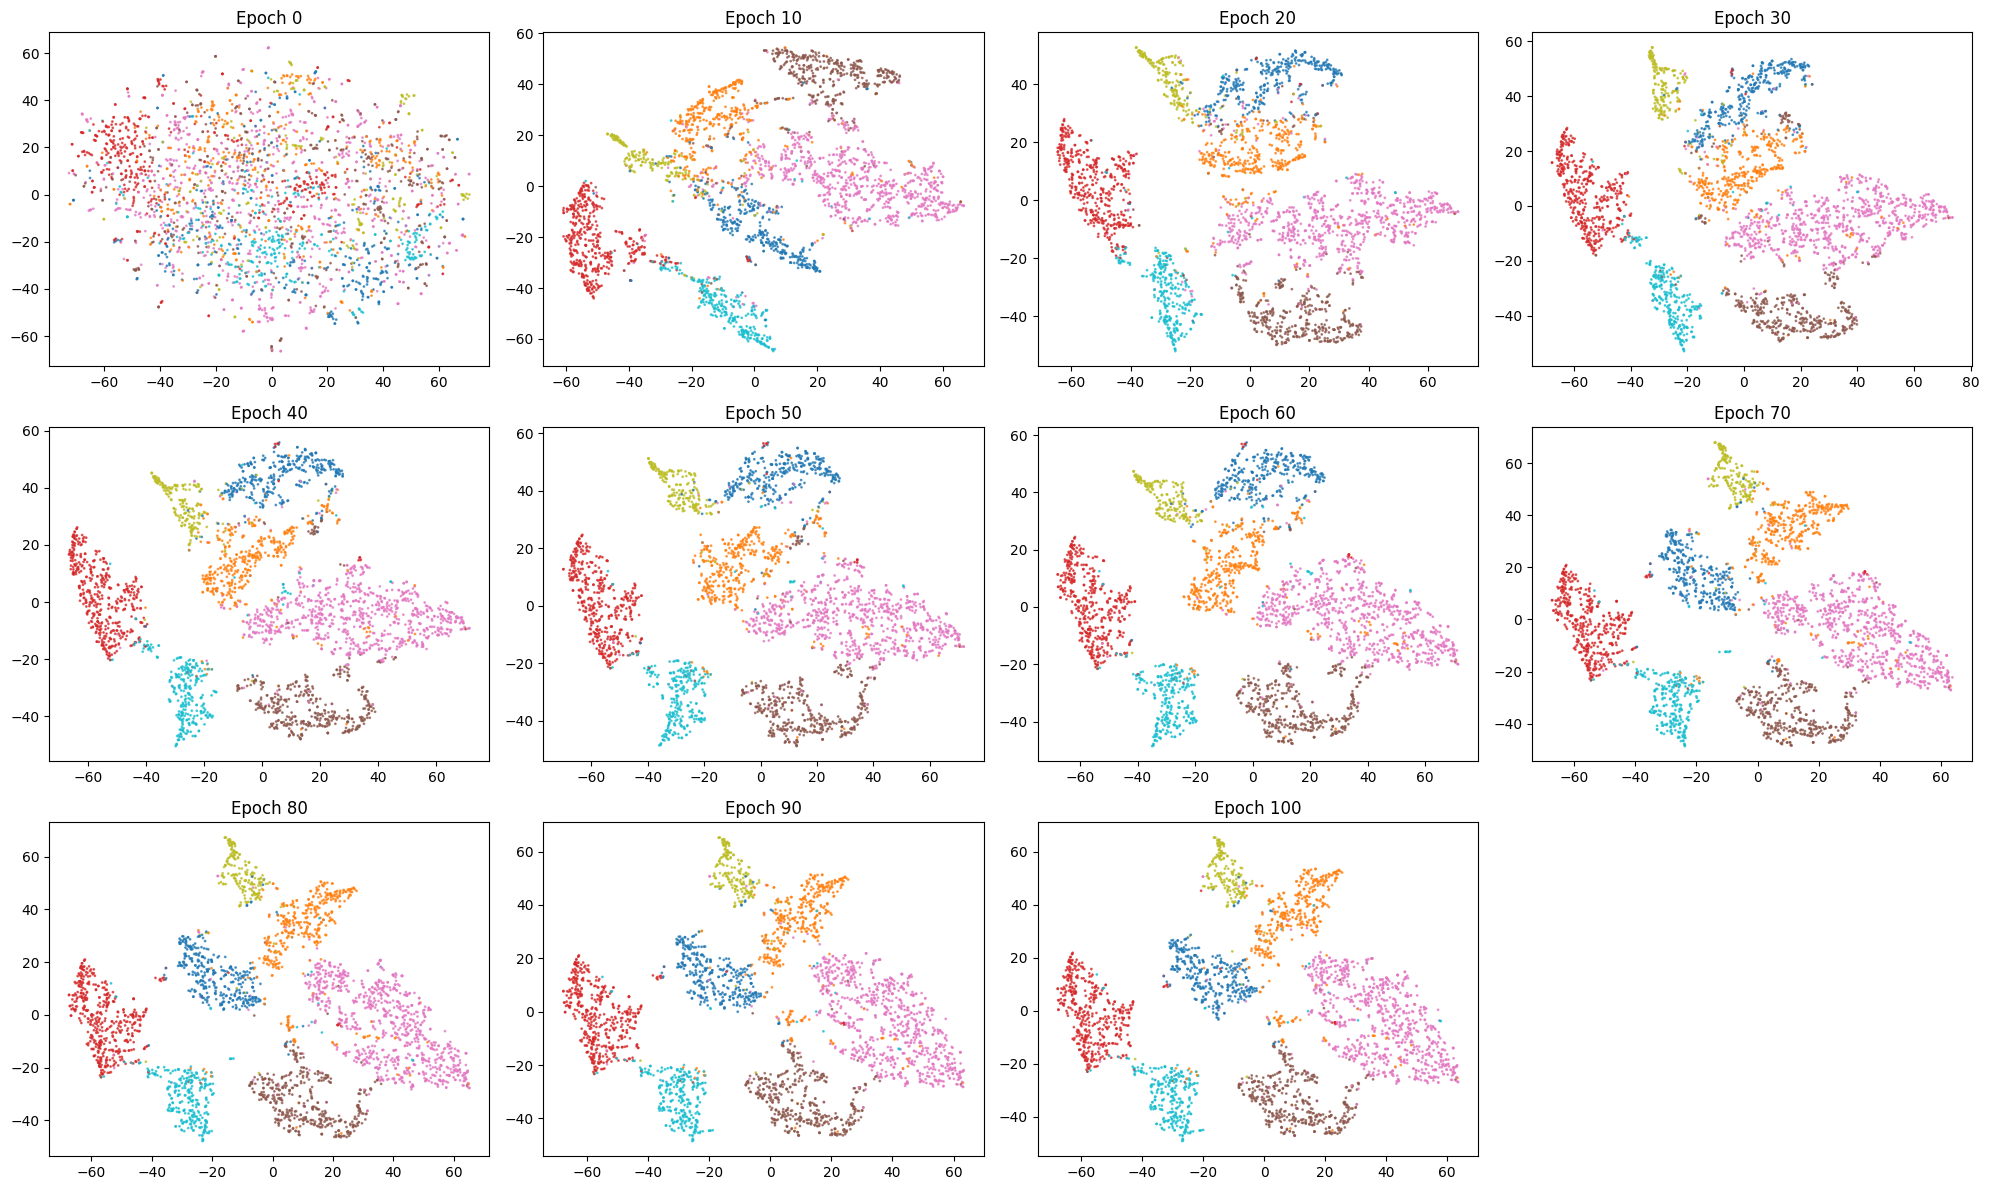

In [ ]:
# embedding is saved every 10 epochs
fig, axs = plt.subplots(3, 4, figsize=(20, 12))
axs = axs.flatten()

labels = data.y.cpu().numpy()

tsne_results = {}
for i, (epoch, eb) in enumerate(embeddings.items()):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(eb)
    tsne_results[epoch] = X_tsne

    scatter = axs[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=1, alpha=0.7)
    axs[i].set_title(f'Epoch {epoch}')
    # axs[i].axis('off')

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

# cbar = fig.colorbar(scatter, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)
# cbar.set_label('Node Class')
plt.savefig('4c_p30.png', dpi=425, bbox_inches='tight')
plt.tight_layout()
plt.show()


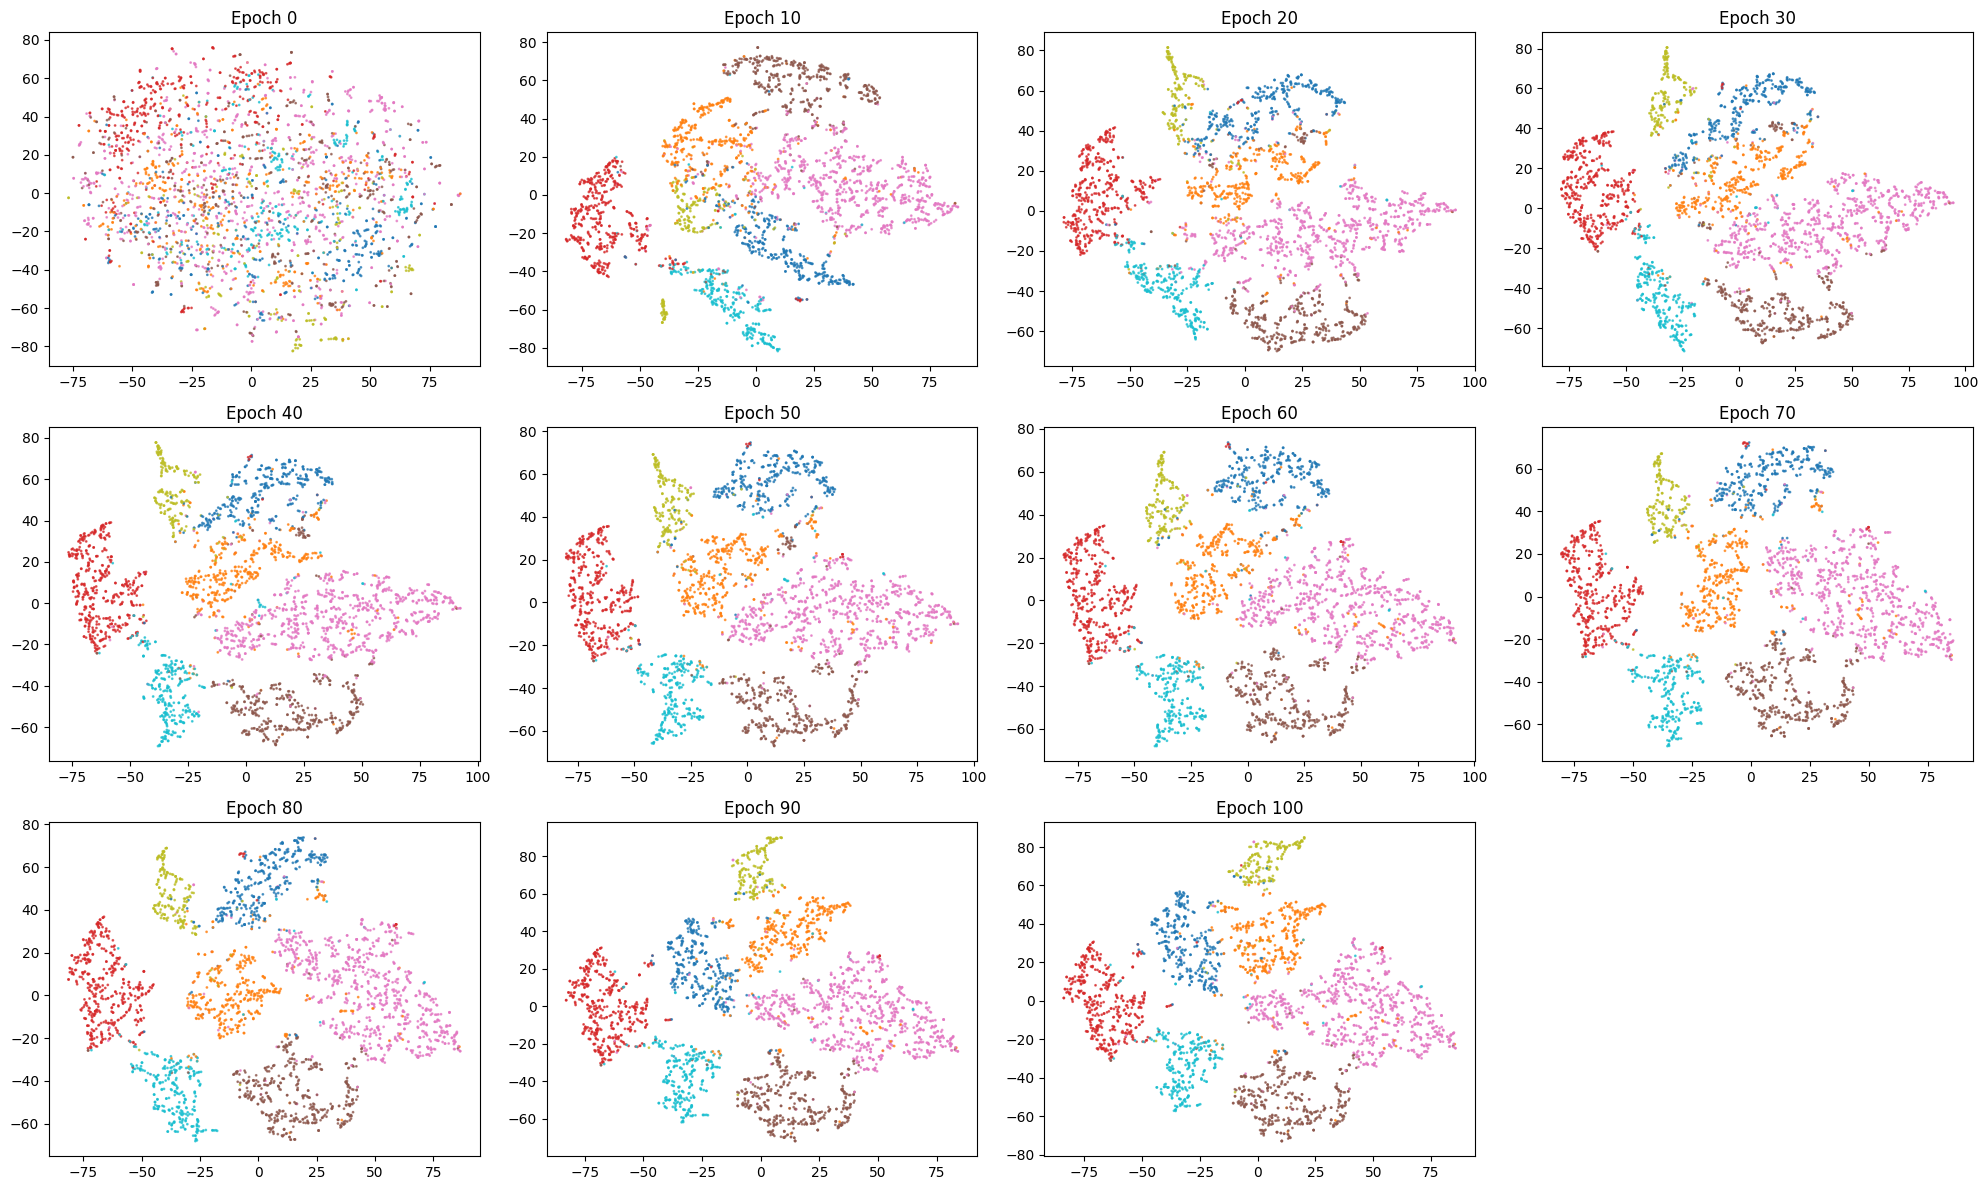

In [ ]:
# change perplexity to 15, resulting in same 7 clusters
"""
fig, axs = plt.subplots(3, 4, figsize=(20, 12))
axs = axs.flatten()

for i, (epoch, eb) in enumerate(embeddings.items()):
    tsne = TSNE(n_components=2, perplexity=15, random_state=42)
    X_tsne = tsne.fit_transform(eb)

    labels = data.y.cpu().numpy()

    scatter = axs[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=1, alpha=0.7)
    axs[i].set_title(f'Epoch {epoch}')

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()
"""

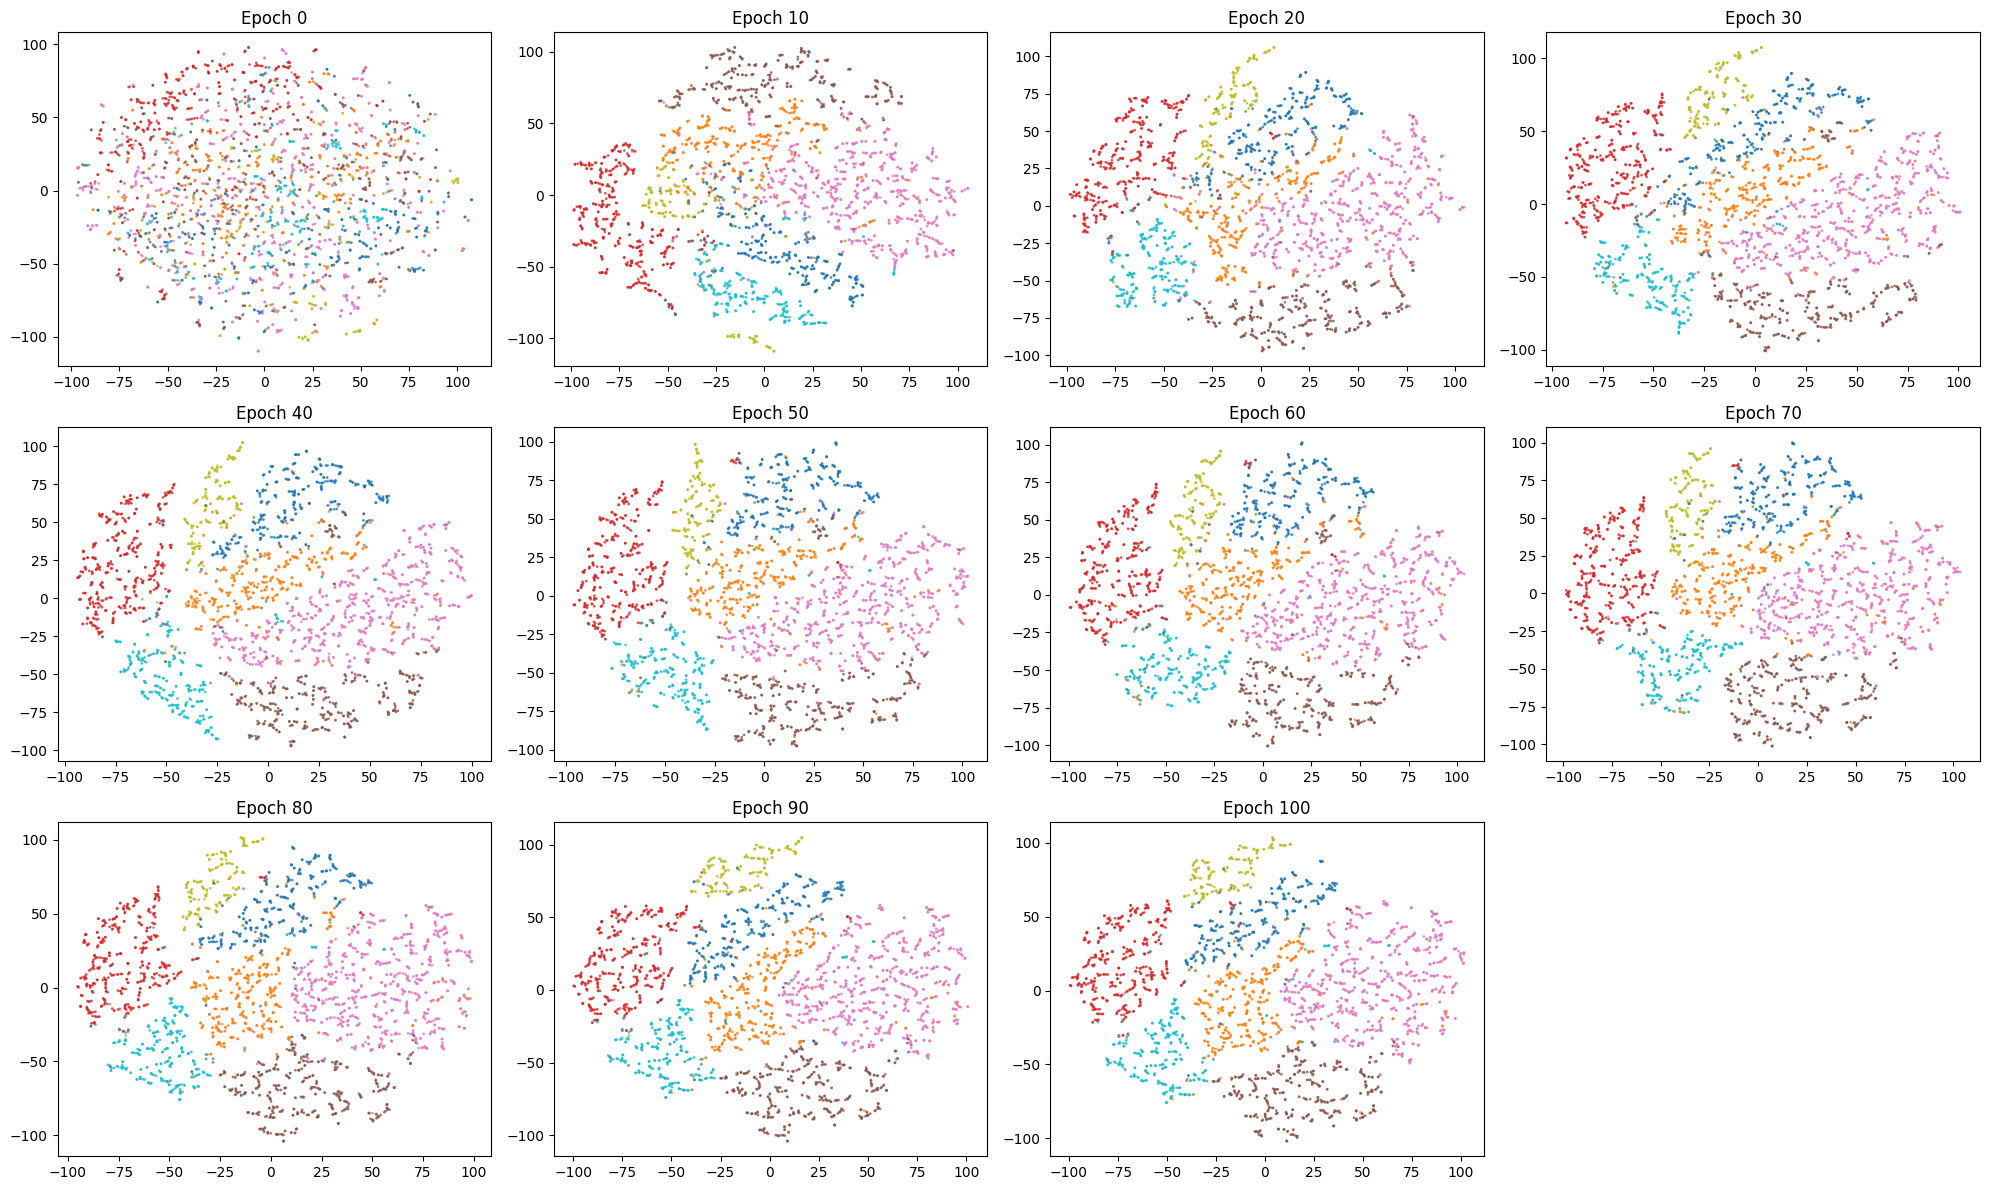

In [ ]:
# change perplexity to 5
fig, axs = plt.subplots(3, 4, figsize=(20, 12))
axs = axs.flatten()

labels = data.y.cpu().numpy()

tsne_results = {}
for i, (epoch, eb) in enumerate(embeddings.items()):
    tsne = TSNE(n_components=2, perplexity=5, random_state=42)
    X_tsne = tsne.fit_transform(eb)
    tsne_results[epoch] = X_tsne

    scatter = axs[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=1, alpha=0.7)
    axs[i].set_title(f'Epoch {epoch}')
    # axs[i].axis('off')

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

# cbar = fig.colorbar(scatter, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)
# cbar.set_label('Node Class')
plt.savefig('4c_p5.png', dpi=425, bbox_inches='tight')
plt.tight_layout()
plt.show()


## (d)
Make an animation of your embeddings’ evolution as the model trains. What can we learn from this animation?

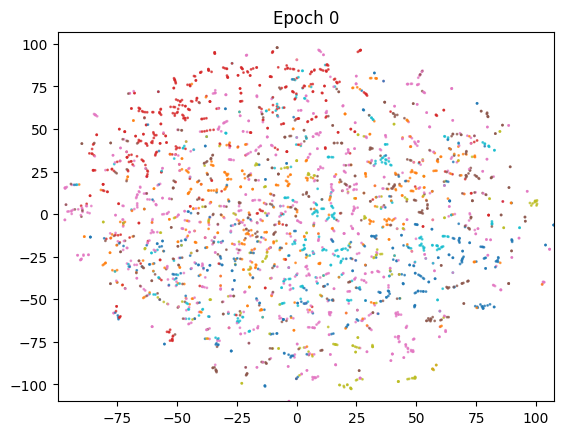

In [ ]:
import matplotlib.animation as animation

fig, ax = plt.subplots()
epochs = sorted(tsne_results.keys())


all_points = np.concatenate([tsne_results[epoch] for epoch in epochs])
x_min, x_max = all_points[:, 0].min(), all_points[:, 0].max()
y_min, y_max = all_points[:, 1].min(), all_points[:, 1].max()

def update(i):
    ax.clear()
    X_tsne = tsne_results[epochs[i]]
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=1, alpha=0.7)
    ax.set_title(f'Epoch {epochs[i]}')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)


ani = animation.FuncAnimation(fig=fig, func=update, frames=len(epochs), interval=2000)
ani.save('4d_p5.gif', writer='imagemagick')


Over time, clusters of data points form and become more defined. In the beginning, the embeddings may change significantly between epochs, but as training progresses, they start to stabilize. For example, when we set the perplexity value to 30, the visualization stabilizes around epoch 20, forming 7 clusters. When we choose a relatively smaller perplexity value, like 5, the visualization shows 7 clusters with clearer boundaries starting from epoch 60.


